# Transition Elements

Here, we compute transition elements of the form $(\psi_{\text{resonance},\theta}|r_\theta|\psi_{\text{bound}, \theta})$, plot these elements for multiple $\theta$, and compare these results to the EC-backrotated result at $\theta=0$.

In [1]:
from dvr import *

In [17]:
# define system parameters
n = 1024                         # number of DVR grid points
phi = pi / 6                     # rotation angle
real_res = 0.25823 - 1j*0.16433  # expected value of resonance
real_bound = -2.5434016 + 1j*0   # due to finite volume, there will be a small imaginary component from CSM
L = 40.0                         # system size

save_plots = False               # save plots or not

gauss_p = lambda r: -10 * exp(-r**2) # potential (supports a p-wave resonance and s-wave bound state)

In [18]:
# find resonance
pres_system = DVR(n, L, rotation_angle=phi, potential=gauss_p, l=1)
res_eigval, res_state = pres_system.closest_to_resonance(resonance=real_res)
res_eigval = res_eigval[0]
res_state = res_state[:, 0] / sqrt(np.sum(res_state[:, 0]**2)) # c-normalizing just in case

print(f"P-wave resonance at phi = {phi:.3f} has energy = {np.real(res_eigval):.3f} + i{np.imag(res_eigval):.3f}")

P-wave resonance at phi = 0.524 has energy = 0.258 + i-0.164


In [19]:
# find bound state
sbound_system = DVR(n, L, rotation_angle=phi, potential=gauss_p, l=0)
bound_eigval, bound_state = sbound_system.closest_to_resonance(resonance=real_bound) # not a resonance, but it's too late to change the name of the fx
bound_eigval = bound_eigval[0]
bound_state = bound_state[:, 0]/ sqrt(np.sum(bound_state[:, 0]**2)) # c-normalizing just in case

print(f"S-wave bound state at phi = {phi:.3f} has energy = {np.real(bound_eigval):.3f} + i{np.imag(bound_eigval):.3f}")

S-wave bound state at phi = 0.524 has energy = -2.543 + i0.000


In [20]:
# find transition amplitude (p-wave res | r_theta | s-wave bound)
transition_amplitude = DVR.compute_transition_element(L, bound_state, res_state, rotation_angle=phi, operator="E1")
print(f"Transition element (p-wave resonance | r_theta | s-wave bound state) for phi = {phi:.3f} is\
    {np.real(transition_amplitude):.3f} + i{np.imag(transition_amplitude):.3f}")

Transition element (p-wave resonance | r_theta | s-wave bound state) for phi = 0.524 is    0.963 + i-0.321


### Compute resonance energy, bound state energy, and transition elements as $L$ varies.

In [21]:
Ls = np.linspace(5, 50, 250)
res_eigvals, bound_eigvals = [], []
transition_elements = []
for L in Ls:
    sbound_system = DVR(n, L, rotation_angle=phi, potential=gauss_p, l=0)
    pres_system = DVR(n, L, rotation_angle=phi, potential=gauss_p, l=1)

    res_eigval, res_state = pres_system.closest_to_resonance(resonance=real_res)
    bound_eigval, bound_state = sbound_system.closest_to_resonance(resonance=real_bound)

    t_elem = DVR.compute_transition_element(L, bound_state[:, 0], res_state[:, 0], rotation_angle=phi, operator="E1")

    res_eigvals.append(res_eigval[0])
    bound_eigvals.append(bound_eigval[0])
    transition_elements.append(t_elem)

res_eigvals = np.array(res_eigvals)
bound_eigvals = np.array(bound_eigvals)
transition_elements = np.array(transition_elements)    

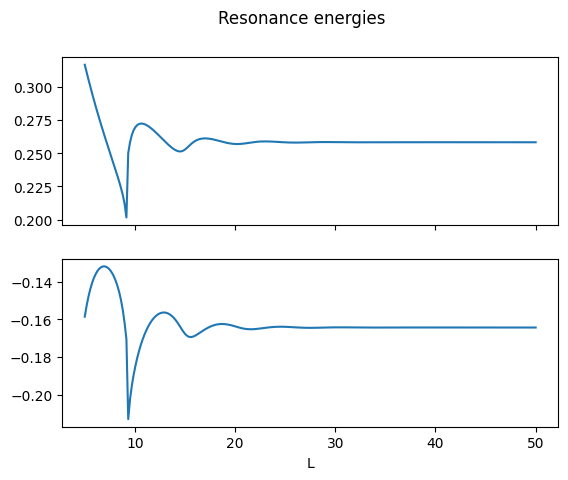

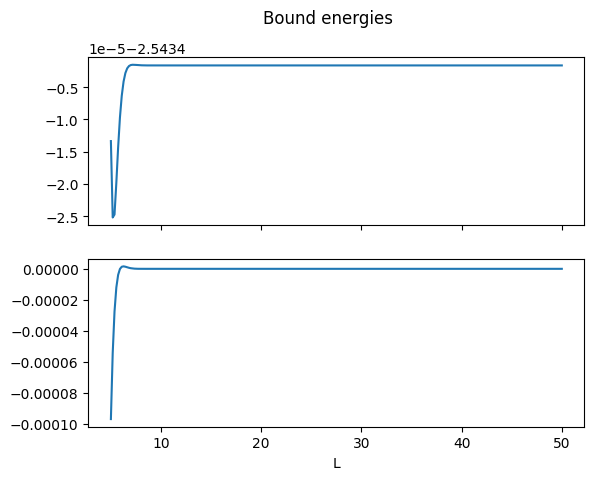

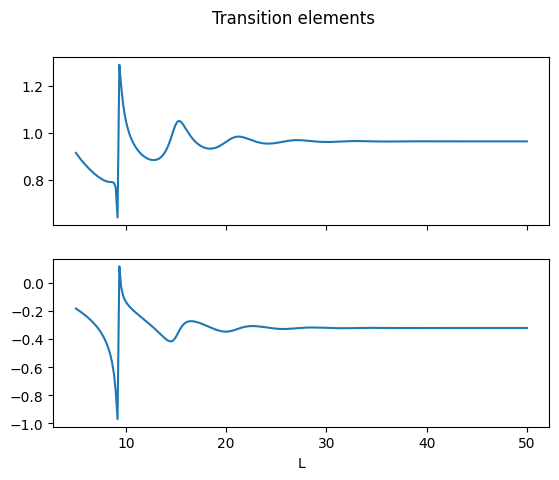

In [22]:
plot_ys = [res_eigvals, bound_eigvals, transition_elements]
titles = ['Resonance energies', 'Bound energies', 'Transition elements']
for i, y in enumerate(plot_ys):
    fig, [ax1, ax2] = plt.subplots(nrows=2, ncols=1, sharex=True)
    ax1.plot(Ls, np.real(y), label='Real')
    ax2.plot(Ls, np.imag(y), label='Imag')
    ax2.set_xlabel("L")
    fig.suptitle(titles[i])
    plt.show()

### Compute transition amplitudes for many rotation angles to see how it varies

In [23]:
phis = np.linspace(pi/7.5, pi/4, 50)
res_system = DVR(n, L, rotation_angle=phi, potential=gauss_p, l=1)
bound_system = DVR(n, L, rotation_angle=phi, potential=gauss_p, l=0)

res_eigvals = []
bound_eigvals = []
transition_elements = []
for phi in phis:
    res_system.reset_rotation_angle(phi)
    bound_system.reset_rotation_angle(phi)
    
    res_energy, res_state = res_system.closest_to_resonance(resonance=real_res)
    bound_energy, bound_state = bound_system.closest_to_resonance(resonance=real_bound)

    t_elem = DVR.compute_transition_element(L, bound_state[:, 0], res_state[:, 0], rotation_angle=phi, operator="E1")
    
    res_eigvals.append(res_energy[0])
    bound_eigvals.append(bound_energy[0])
    transition_elements.append(t_elem)

res_eigvals = np.array(res_eigvals)
bound_eigvals = np.array(bound_eigvals)
transition_elements = np.array(transition_elements)

In [24]:
# compute the median and std
res_mean, res_std = np.mean(res_eigvals), np.std(np.real(res_eigvals)) + 1j*np.std(np.imag(res_eigvals))
print(f"Resonance energy: {res_mean:.3f} +- {res_std:.5f}")

bound_mean, bound_std = np.mean(bound_eigvals), np.std(np.real(bound_eigvals)) + 1j*np.std(np.imag(bound_eigvals))
print(f"Bound energy: {bound_mean:.3f} +- {bound_std:.5f}")

telem_mean, telem_std = np.mean(transition_elements), np.std(np.real(transition_elements)) + 1j*np.std(np.imag(transition_elements))
print(f"Transition element: {telem_mean:.3f} +- {telem_std:.5f}")

Resonance energy: 0.258-0.164j +- 0.00001+0.00002j
Bound energy: -2.543+0.000j +- 0.00000+0.00000j
Transition element: 0.963-0.322j +- 0.00124+0.00024j


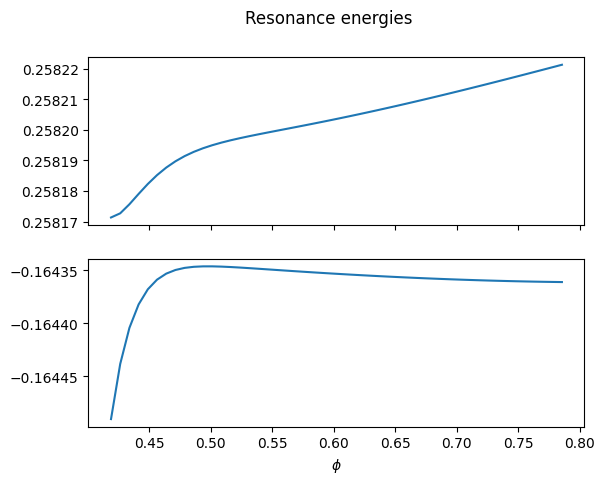

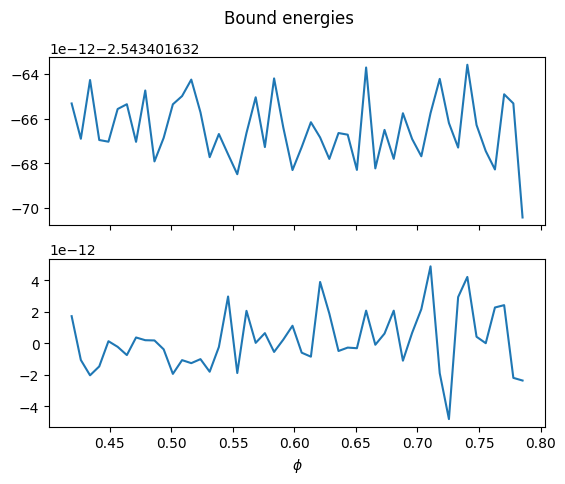

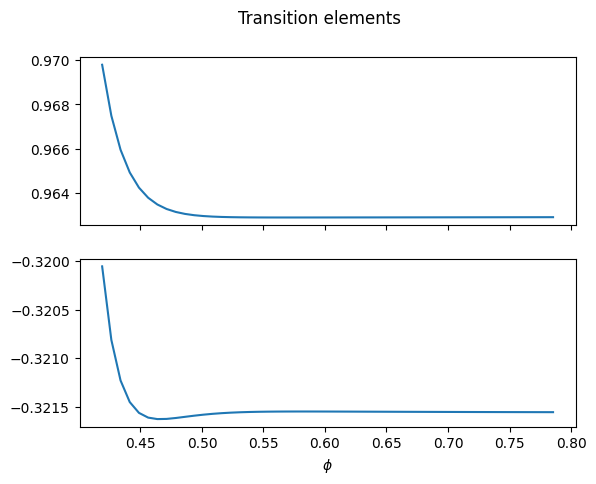

In [25]:
plot_ys = [res_eigvals, bound_eigvals, transition_elements]
titles = ['Resonance energies', 'Bound energies', 'Transition elements']
for i, y in enumerate(plot_ys):
    fig, [ax1, ax2] = plt.subplots(nrows=2, ncols=1, sharex=True)
    ax1.plot(phis, np.real(y), label='Real')
    ax2.plot(phis, np.imag(y), label='Imag')
    ax2.set_xlabel(r"$\phi$")
    fig.suptitle(titles[i])
    plt.show()